This problem has the following inputs:
1. Frequency, in Hertzs.
2. Angle of attack, in degrees.
3. Chord length, in meters.
4. Free-stream velocity, in meters per second.
5. Suction side displacement thickness, in meters.

The only output is:
6. Scaled sound pressure level, in decibels.

In [96]:
import pandas as pd
import numpy as np

In [97]:
df  = pd.read_csv('airfoil_self_noise.dat',sep="\t",header=None)

In [98]:
df.head()

,0,1,2,3,4,5
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [99]:
df.columns=["Frequency","Angle of attack","Chord length","Free-stream velocity","Suction side","pressure level"]

In [100]:
df.head()

,Frequency,Angle of attack,Chord length,Free-stream velocity,Suction side,pressure level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [101]:
df.isnull().sum()

Frequency               0
Angle of attack         0
Chord length            0
Free-stream velocity    0
Suction side            0
pressure level          0
dtype: int64

In [102]:
X = df.drop(columns='pressure level')
y = df['pressure level']

In [103]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

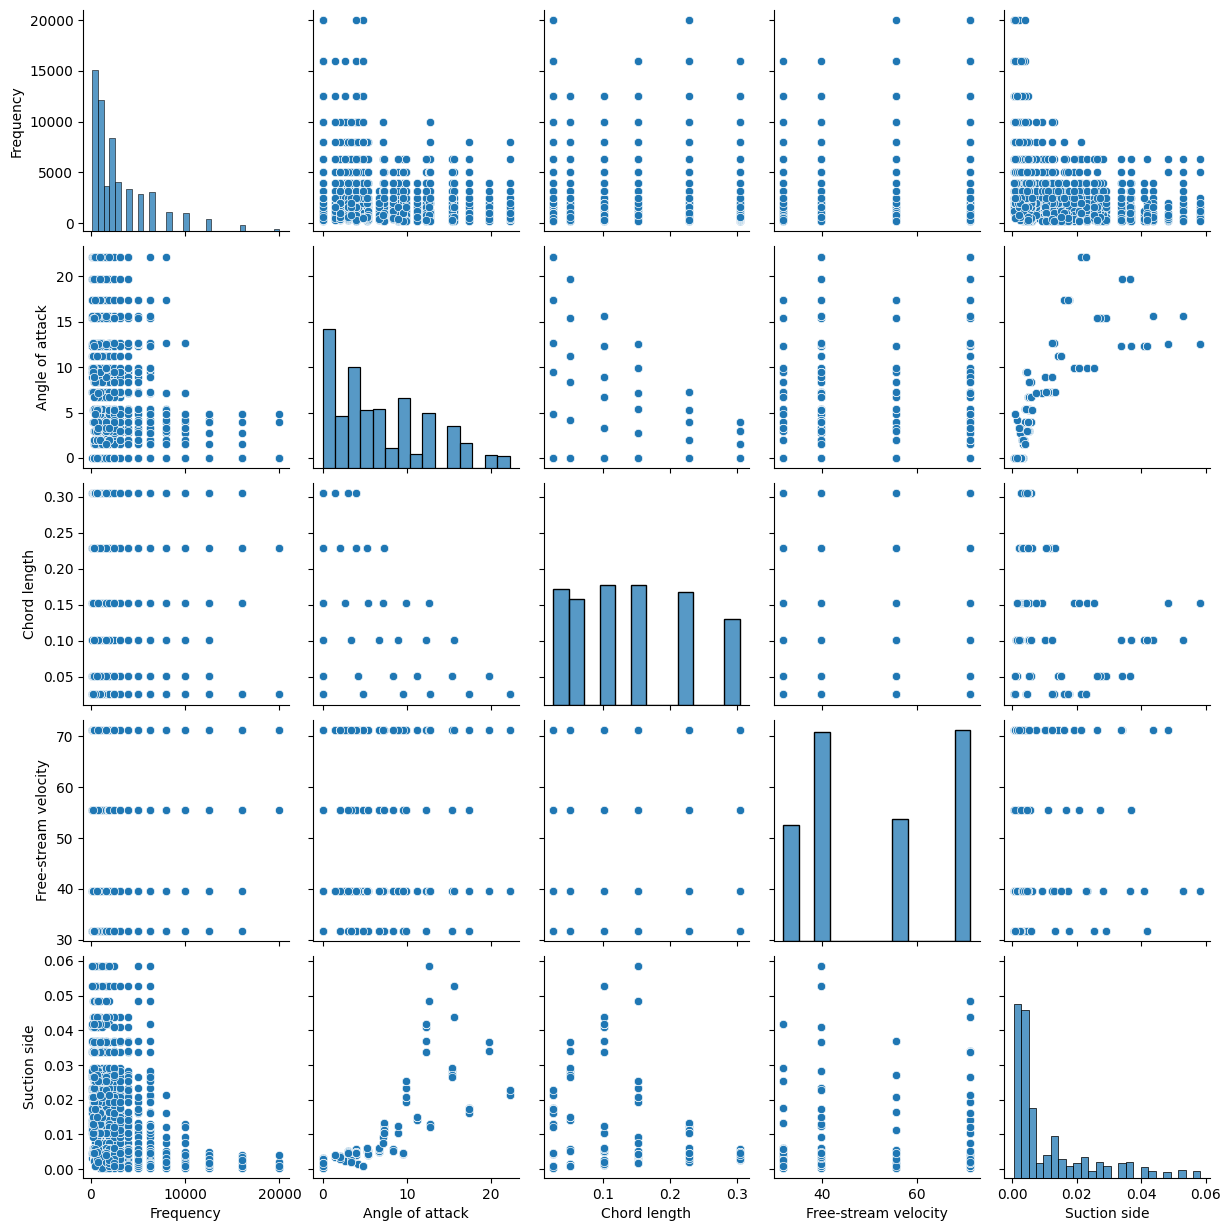

In [104]:
import seaborn as sns
sns.pairplot(X_train)

In [105]:
import matplotlib.pyplot as plt
X_train.corr()

,Frequency,Angle of attack,Chord length,Free-stream velocity,Suction side
Frequency,1.000000,-0.279410,0.012930,0.137387,-0.233708
Angle of attack,-0.279410,1.000000,-0.507163,0.050670,0.760036
Chord length,0.012930,-0.507163,1.000000,0.005318,-0.226070
Free-stream velocity,0.137387,0.050670,0.005318,1.000000,0.003225
Suction side,-0.233708,0.760036,-0.226070,0.003225,1.000000


<Axes: ylabel='Frequency'>

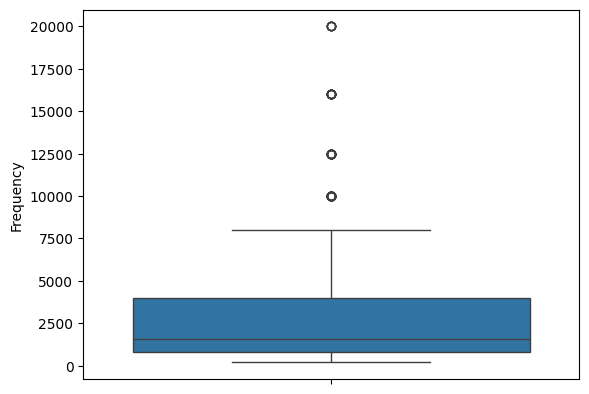

In [106]:
sns.boxplot(X_train['Frequency'])

<Axes: xlabel='Frequency', ylabel='pressure level'>

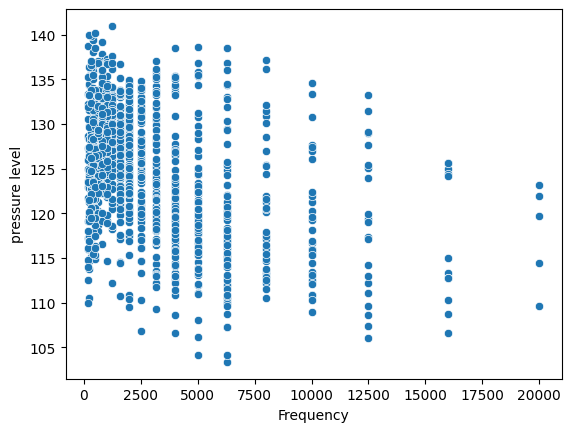

In [107]:
sns.scatterplot(x=X_train['Frequency'], y=y_train)

In [108]:
len(df['pressure level'].unique())

1456

<Axes: ylabel='pressure level'>

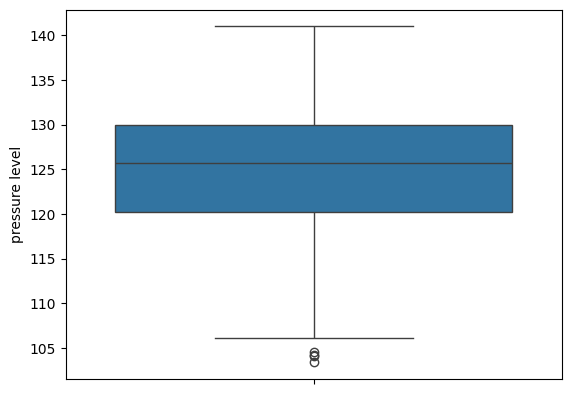

In [109]:
sns.boxplot(df['pressure level'])

In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,root_mean_squared_error

In [111]:
linear = LinearRegression()
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
y_pred = linear.predict(X_test)
print("Mean Sqaured error", mean_squared_error(y_test, y_pred))
print("Root mean Sqaured Error", root_mean_squared_error(y_test, y_pred))
print("R2 Score", r2_score(y_test, y_pred))
# Accuracy is not applicable for regression tasks


Mean Sqaured error 22.128643318247352
Root mean Sqaured Error 4.704109194974895
R2 Score 0.558297975489727


### Lasso 

In [113]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso = Lasso(max_iter=1000)
params = {"alpha":[0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_regression = GridSearchCV(lasso,param_grid=params,cv=5)
lasso_regression.fit(X_train,y_train)
lasso_predicted = lasso_regression.predict(X_test)
r2_score(y_test,lasso_predicted)

0.5581090834357036

### Rigde

In [114]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()

# Define the grid of alpha values to search.
# Alpha controls the strength of the regularization.
# Larger alpha = stronger regularization.
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Use GridSearchCV to find the best alpha through 5-fold cross-validation
# cv=5 means the training data will be split into 5 parts, and the model
# will be trained 5 times, each time using a different part as the validation set.
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5,
                           scoring='neg_mean_squared_error', verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best alpha value found
best_alpha = grid_search.best_params_['alpha']
print(f"--- Best Alpha Found ---")
print(f"The optimal alpha value is: {best_alpha}\n")

# Use the best model found by the grid search
model = grid_search.best_estimator_

# Print the model's coefficients and intercept
print("--- Model Coefficients (with Ridge Regularization) ---")
print(f"Intercept: {model.intercept_}")
coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeffs)
print("\n")


# Step 6: Evaluate the Model

# Make predictions on the test data using the best model
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Ridge Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
--- Best Alpha Found ---
The optimal alpha value is: 0.001

--- Model Coefficients (with Ridge Regularization) ---
Intercept: 132.5387681620582
                      Coefficient
Frequency               -0.001272
Angle of attack         -0.409021
Chord length           -34.517897
Free-stream velocity     0.098084
Suction side          -137.723139


--- Ridge Model Evaluation ---
Mean Absolute Error (MAE): 3.67
Mean Squared Error (MSE): 22.14
Root Mean Squared Error (RMSE): 4.71
R-squared (R²): 0.56


### Decision Tree

In [115]:
from sklearn.tree import DecisionTreeRegressor

In [116]:
tree = DecisionTreeRegressor(random_state=42)

In [117]:
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
params_d = {'max_depth':[3,5,7,8,10,15,20,30,40]}
grid_search = GridSearchCV(tree,param_grid=params_d,cv=5)
grid_search.fit(X_train,y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"--- Best max_depth Found ---")
print(f"The optimal max_depth for the tree is: {best_depth}\n")

# Use the best model found by the grid search
# model = grid_search.best_estimator_


# Step 6: Evaluate the Model

# Make predictions on the test data
y_pred = grid_search.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Decision Tree Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print("\n")



--- Best max_depth Found ---
The optimal max_depth for the tree is: 20

--- Decision Tree Model Evaluation ---
Mean Absolute Error (MAE): 1.73
Mean Squared Error (MSE): 5.88
Root Mean Squared Error (RMSE): 2.42
R-squared (R²): 0.88




### Random Forest

In [118]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV



In [119]:
random_forest = RandomForestRegressor(random_state=42,n_jobs=-1)

In [120]:
params_r = {'max_depth':[3,5,7,8,10,15,20,30,40],
                         'n_estimators':[100,200]
                         }
model = GridSearchCV(random_forest,param_grid=params_r,cv=5)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Random Forest Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print("\n")





--- Random Forest Model Evaluation ---
Mean Absolute Error (MAE): 1.30
Mean Squared Error (MSE): 3.27
Root Mean Squared Error (RMSE): 1.81
R-squared (R²): 0.93




In [131]:
import pickle
pickle.dump(model, open('model_1.pkl', 'wb'))

In [123]:
pickled_model = pickle.load(open('model_1.pkl', 'rb'))
pickled_model.predict(X_test)

array([123.619945, 119.151155, 119.32669 , 137.147135, 134.211955,
       122.7297  , 123.922145, 134.512085, 133.752565, 127.955255,
       126.1295  , 113.058035, 133.29891 , 133.09458 , 124.51422 ,
       108.822065, 129.510555, 130.04756 , 128.293   , 123.41987 ,
       124.700645, 127.652715, 111.02277 , 126.14563 , 124.286755,
       126.026505, 129.192825, 131.501815, 110.282705, 129.95192 ,
       131.615435, 122.11821 , 128.011915, 119.685685, 119.320675,
       133.98815 , 133.850995, 130.237245, 120.709925, 111.948065,
       125.245515, 134.930145, 127.051415, 121.811475, 125.847595,
       134.5458  , 130.02649 , 118.55193 , 122.17074 , 133.556225,
       132.7494  , 114.145145, 129.2462  , 127.195715, 126.964535,
       120.69033 , 123.56137 , 129.403735, 119.758175, 120.06674 ,
       125.75717 , 134.308205, 130.91766 , 133.21984 , 118.48335 ,
       125.144845, 123.56396 , 120.020155, 126.00003 , 129.74666 ,
       129.20326 , 129.92203 , 128.51806 , 117.149535, 129.571

In [124]:
X_test.iloc[51]         

Frequency               8000.000000
Angle of attack            1.500000
Chord length               0.304800
Free-stream velocity      71.300000
Suction side               0.003367
Name: 76, dtype: float64

In [125]:
dict_test={
"Frequency": 9,
"Angle of attack" : 8,
"Chord length" : 10,
"Free-stream velocity": 1,
"Suction side" : 7
}

In [130]:
list(dict_test.values())

[9, 8, 10, 1, 7]

In [129]:
pickled_model.predict([[9, 8, 10, 1, 7]])[0]

d:\Data_Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(117.32725499999998)